<a href="https://colab.research.google.com/github/Prithujit-Ghosh/Dimensionality_Reduction_TMP/blob/main/t_SNE_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**t-SNE Implementation**

**Notebook Structure:**

1. Importing Necessary Libraries

2. Importing The Dataset

3. Data Cleaning and Preprocessing

4. Initial Analysis

5. Data Quality Assessment
6. Univariate analysis of the numerical columns
7. Feature Scaling
8. t-SNE Implementation
9. t-SNE Visualization

**1. Importing Necessary Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**2. Importing The Dataset**

In [ ]:
df_original=pd.read_csv("student_grades.csv")

**3. Data Cleaning and Preprocessing**

In [ ]:
#Checking for duplicate in the dataset
print(f"Number of duplicate entries: {df_original.duplicated().sum()}")

Number of duplicate entries: 0


In this case there are no duplicates in the dataset; treatment of duplicates is not required.

**4. Initial Analysis**

In [ ]:
df_original.shape

(100, 9)

In [ ]:
df_original.columns

Index(['student_id', 'math', 'science', 'cs', 'band', 'english', 'history',
       'spanish', 'physed'],
      dtype='object')

In [ ]:
df_original.head()

,student_id,math,science,cs,band,english,history,spanish,physed
0,1,46,48,50,74,34,44,39,73
1,2,66,65,65,66,74,80,75,63
2,3,55,53,50,76,71,72,76,71
3,4,53,57,53,80,77,77,85,82
4,5,55,62,58,67,82,77,78,60


In [ ]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   student_id  100 non-null    int64
 1   math        100 non-null    int64
 2   science     100 non-null    int64
 3   cs          100 non-null    int64
 4   band        100 non-null    int64
 5   english     100 non-null    int64
 6   history     100 non-null    int64
 7   spanish     100 non-null    int64
 8   physed      100 non-null    int64
dtypes: int64(9)
memory usage: 7.2 KB


**Classifying Variables:**

Numerical:  'math', 'science', 'cs', 'band', 'english', 'history',
       'spanish', 'physed'

Others: 'student_id'

**Dropping Redundant Columns:**

In [ ]:
df_or2=df_original.drop(columns=['student_id'])

In [ ]:
df_or2.head()

,math,science,cs,band,english,history,spanish,physed
0,46,48,50,74,34,44,39,73
1,66,65,65,66,74,80,75,63
2,55,53,50,76,71,72,76,71
3,53,57,53,80,77,77,85,82
4,55,62,58,67,82,77,78,60


In [ ]:
df_or2.columns

Index(['math', 'science', 'cs', 'band', 'english', 'history', 'spanish',
       'physed'],
      dtype='object')

**5. Data Quality Assessment**

In [ ]:
df_or2.isnull().sum()

,0
math,0
science,0
cs,0
band,0
english,0
history,0
spanish,0
physed,0


**Analysis**: The preceding results clearly states that there are no missing values.

**6. Univariate analysis of the numerical columns**

In [ ]:
df_or2.describe()

,math,science,cs,band,english,history,spanish,physed
count,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000
mean,53.050000,53.220000,52.750000,70.04000,60.970000,63.600000,65.560000,67.610000
std,13.912697,14.003304,13.462537,6.27794,17.307939,17.476102,18.405269,8.069014
min,21.000000,22.000000,28.000000,60.00000,30.000000,28.000000,31.000000,51.000000
25%,45.000000,44.750000,44.000000,64.00000,48.000000,50.750000,49.500000,62.750000
50%,51.500000,52.000000,50.000000,71.00000,60.500000,65.000000,68.500000,67.000000
75%,58.000000,59.250000,58.250000,75.00000,74.000000,78.000000,79.000000,74.250000
max,93.000000,94.000000,92.000000,80.00000,90.000000,98.000000,99.000000,84.000000


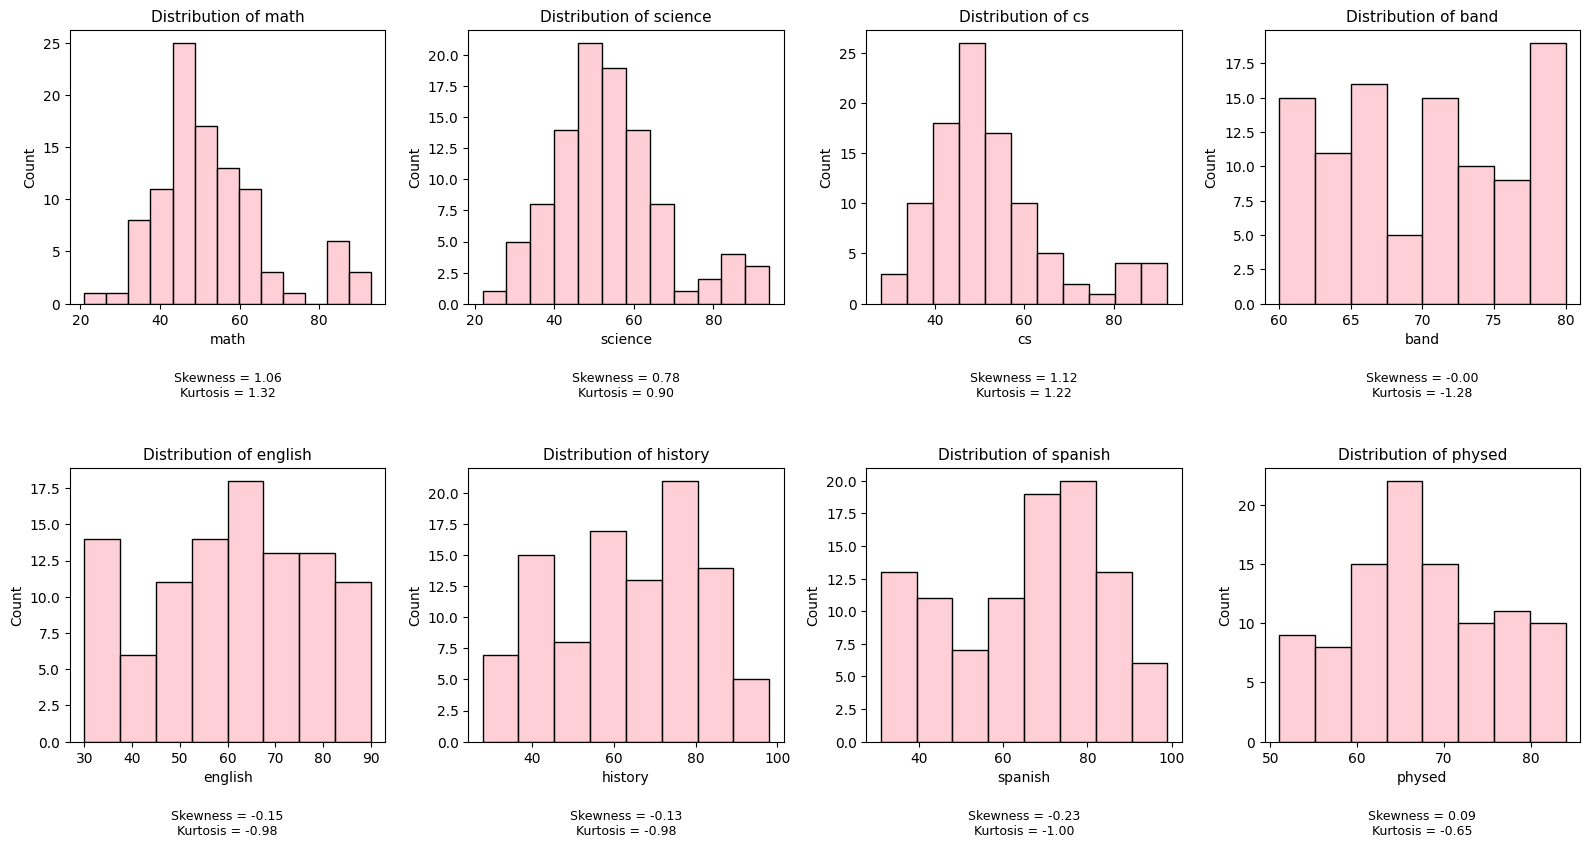

In [ ]:
features_to_check = ['math', 'science', 'cs', 'band', 'english', 'history', 'spanish',
       'physed']
plt.figure(figsize=(16, 12))

for i, col in enumerate(features_to_check):
    ax = plt.subplot(3, 4, i + 1)  # Create subplot

    # Plot histogram
    sns.histplot(data=df_or2, x=col, color="pink", ax=ax)

    # Calculate skewness & kurtosis
    skew_val = df_or2[col].skew()
    kurt_val = df_or2[col].kurt()

    # Add caption below each subplot
    ax.text(0.5, -0.25, f"Skewness = {skew_val:.2f}\nKurtosis = {kurt_val:.2f}",
            transform=ax.transAxes,
            ha="center", va="top", fontsize=9, color="black")

    # Title for each subplot
    ax.set_title(f'Distribution of {col}', fontsize=11)

# Adjust layout to make space for captions
plt.tight_layout()
plt.subplots_adjust(hspace=0.6)  # More vertical space

plt.show()

##**Insights**
####**Subject Difficulty & Performance Buckets:**
The subjects clearly divide into three distinct performance groups based on their means and distributions:

**The "Hard" Subjects (STEM):** Math, Science, and CS have the lowest averages (approx. 52-53). These distributions are right-skewed (positive skewness), meaning most students scored on the lower end, with only a few high-achievers pulling the mean up.

**The "Middle" Subjects (Humanities)**: English, History, and Spanish show moderate performance with means between 59 and 66. These are slightly left-skewed (negative skewness), suggesting that more students are scoring above the average than below it.

**The "High-Success" Subjects:** Band and PhysEd have the highest averages (70 and 67 respectively). These subjects also have the lowest standard deviations, meaning student performance is more consistent and "grouped" together compared to the wide variety of scores in English or History.

####**Distribution Analysis (Kurtosis & Skew):**
**STEM Peakiness (Leptokurtic):** Math and CS have positive Kurtosis (1.32 and 1.22). This tells us that the scores are heavily concentrated around a specific "average" point with infrequent extreme outliers. It suggests a very standardized level of difficulty where most students hit a "ceiling" or "floor" together.

**The Humanities Gap:** English, History, and Spanish have negative Kurtosis (around -1.0). These distributions are flatter (Platykurtic). This indicates there isn't one "common" grade; instead, students are spread out across a wide range of scores, possibly indicating that these subjects depend more on individual student effort or interest.

**The Band Ceiling:** Band has a Kurtosis of -1.28 and a maximum score of 80 (the lowest "Max" of any subject). This suggests the grading might be capped or the curriculum is designed so that almost everyone reaches a high level of competency but nobody "breaks away" with a 90+.

**7. Feature Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler_ft = scaler.fit_transform(df_or2)
df_scaled = pd.DataFrame(scaler_ft, columns=df_or2.columns)
df_scaled.head()

,math,science,cs,band,english,history,spanish,physed
0,-0.509284,-0.374647,-0.205300,0.633958,-1.566095,-1.127182,-1.450335,0.671353
1,0.935494,0.845468,0.914517,-0.646765,0.756626,0.943152,0.515480,-0.574200
2,0.140866,-0.015790,-0.205300,0.954139,0.582422,0.483078,0.570086,0.422242
3,-0.003612,0.271296,0.018664,1.594500,0.930830,0.770624,1.061540,1.792350
4,0.140866,0.630154,0.391936,-0.486675,1.221171,0.770624,0.679298,-0.947865


**8. t-SNE Implementation**

In [ ]:
from sklearn.manifold import TSNE

#creating an instance of TSNE
tsne=TSNE(n_components=2,random_state=42)

#fitting and transforming data into lower (two) dimentional space
data_tsne=tsne.fit_transform(df_scaled)

#Converting the data into a data frame
df_tsne=pd.DataFrame(data_tsne,columns=["component 1","component 2"])
df_tsne

,component 1,component 2
0,0.330800,-6.146821
1,0.348588,3.492629
2,-2.216990,0.421706
3,-4.383247,0.910974
4,0.777133,2.669885
...,...,...
95,-0.851210,5.890042
96,0.804848,-5.086001
97,3.588965,-4.406519
98,1.629614,-4.664961


**9. t-SNE Visualization**

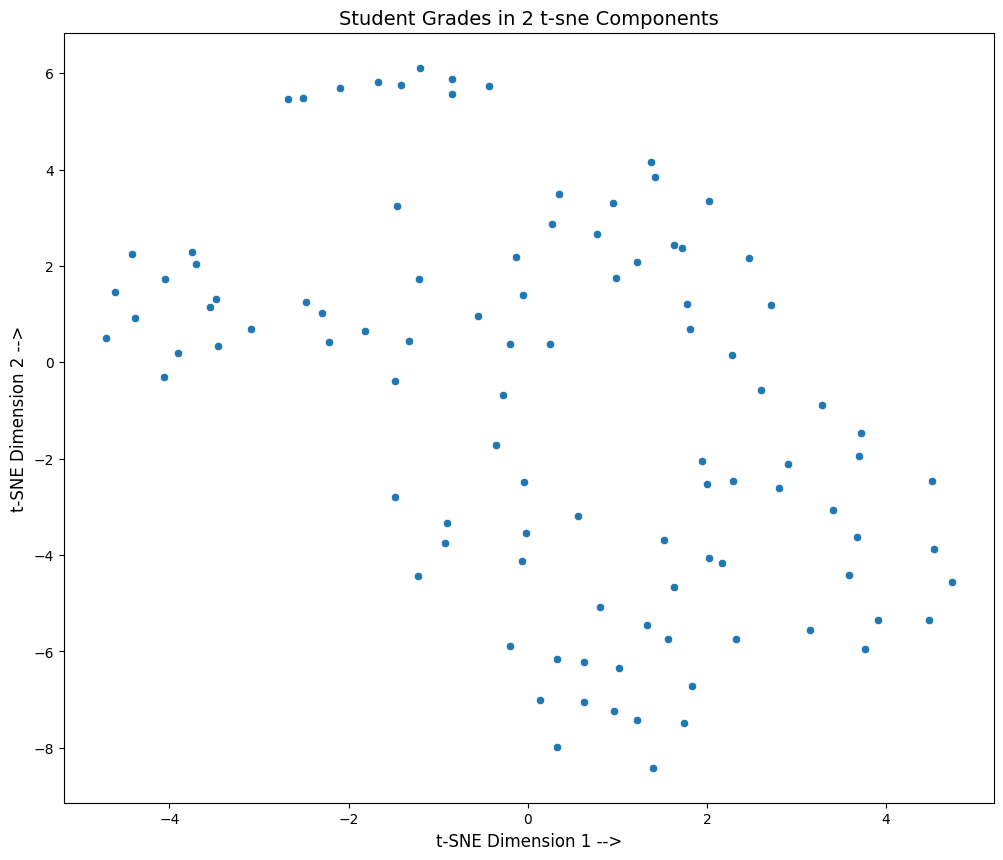

In [ ]:
# Create a figure and axes with a specified size
plt.figure(figsize=(12, 10)) # Adjust width and height as desired

sns.scatterplot(x='component 1', y='component 2', data=df_tsne)
plt.xlabel('t-SNE Dimension 1 -->',size=12)
plt.ylabel('t-SNE Dimension 2 -->',size=12)

plt.title('Student Grades in 2 t-sne Components',size=14)
plt.show()

##**Interpretation:**

1. **Evidence of Academic "Archetypes":** The most striking insight is that the points are not randomly scattered; they form distinct clusters. This suggests that the student population isn't a uniform mix. Instead, students tend to fall into specific academic archetypes—groups that share similar strengths and weaknesses across subjects (e.g., a "STEM-focused" group or a "Humanities-leaning" group).
2. **Identification of Isolated Sub-groups:**

    The "*Top-Tier*" or "*Unique*" Cluster: There is a very distinct, almost horizontal line of points at the top of the plot (y is approximately 5.5). These students have a grade profile that is fundamentally different from everyone else.

    Interpretation: These could be the highest overachievers who excel in every subject, or perhaps a niche group that failed specific subjects but aced others.

    The Left-Hand Cluster: The grouping around x = -4 represents another unique profile. The physical distance between this group and the main mass on the right indicates their performance patterns are highly dissimilar to the "average" student.
3. **The "Mainstream" Gradient:** The large, denser region on the right side of the plot represents the majority of the student body.

    Insights: Unlike the isolated clusters, this area shows a more "continuous" spread. This suggests a gradual variation in grades among these students, likely representing those with more balanced or average performance across the board.

    Sub-clustering: Within this large mass, one can see smaller "pockets" of density. These represent subtle variations—perhaps students who are "good at Math but average at English" versus "average at Math but good at English."